#**Korean Drama Recommendation System: A Content-Based Filtering Approach**

Hello, my name is Vivin Sativa Putri. In this notebook, I would like to share my final project from the course I completed at Dicoding Indonesia. The task is to create recommendation system using either content based filtering or collaborative based filtering.

The method I used in this project was **Content-Based Filtering.** I chose this method because it is simple and easy to implement. Content-Based Filtering is a technique for building recommendation systems by considering the attributes of the items being recommended. For example, if we want to recommend a restaurant, we might consider its location, the type of cuisine it offers, or other attributes related to restaurants the user has previously visited.

In this project, I created a Korean Drama recommendation system. Dramas have many attributes that can be used for recommendations, such as the actors, directors, genres, synopses, and more. For this project, I used actors as the basis for recommendations. The reason was when a user likes a particular drama, they often check the cast and may be curious about other dramas featuring the same actors.
I used data from Kaggle: **Korean Drama from 2015-2023 with Actors & Reviews.** You can find the dataset at this [link](https://www.kaggle.com/datasets/chanoncharuchinda/korean-drama-2015-23-actor-and-reviewmydramalist?select=korean_drama.csv)

Lets get started!

First, we need to import all the module or library that we used in this project. After that we need to import the dataset from kaggle using API

In [1]:
#Data Manipulation
import numpy as np
import pandas as pd

#Visualitation
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as pl

#Preprocessing
from sklearn.feature_extraction.text import TfidfVectorizer

#Modelling Content Based Filtering
from sklearn.metrics.pairwise import cosine_similarity


In [2]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [3]:
# Module to upload file

from google.colab import files
files.upload()

{}

In [4]:
#import dataset from Kaggle using API

!kaggle datasets download -d chanoncharuchinda/korean-drama-2015-23-actor-and-reviewmydramalist
!unzip korean-drama-2015-23-actor-and-reviewmydramalist.zip

Dataset URL: https://www.kaggle.com/datasets/chanoncharuchinda/korean-drama-2015-23-actor-and-reviewmydramalist
License(s): CC0-1.0
 95% 8.00M/8.40M [00:01<00:00, 13.0MB/s]
100% 8.40M/8.40M [00:01<00:00, 8.23MB/s]
Archive:  korean-drama-2015-23-actor-and-reviewmydramalist.zip
  inflating: korean_drama.csv        
  inflating: recommendations.csv     
  inflating: reviews.csv             
  inflating: wiki_actors.csv         


There are four tables in the dataset:

1. korean_drama.csv
2. recommendations.csv
3. reviews.csv
4. wiki_actors.csv

Since we are building a recommendation system based on actors, the only table we need is the fourth one: wiki_actors.csv.

Let's perform an Exploratory Data Analysis on the wiki_actors table.

##  Exploratory Data Analysis (EDA)##

In this section, we will:

1. Examine the data structure (explore the column names, data types for each column, and the number of rows in the dataset).

2. Perform descriptive analysis.

3. Check for missing and duplicate values.

4. Visualization

### Data Structure


In [5]:
#Import dataset
actor = pd.read_csv('wiki_actors.csv')
actor.head(10)

,actor_id,actor_name,drama_name,character_name,role
0,96612cd9-183e-4530-9e0d-d85322e6ec4c,Jang Do Yoon,Sing My Crush,Han Ba Ram,Main Role
1,96612cd9-183e-4530-9e0d-d85322e6ec4c,Jang Do Yoon,Finland Papa,Toto / Seung Yoon,Support Role
2,96612cd9-183e-4530-9e0d-d85322e6ec4c,Jang Do Yoon,My Sweet Dear,Ye Jun,Support Role
3,96612cd9-183e-4530-9e0d-d85322e6ec4c,Jang Do Yoon,Lemon Car Video,Jang Do Yoon (Ep. 1),Main Role
4,b5f2eca0-6e6b-474d-88ad-46f4feaa0a8e,Son Hyun Woo,Sing My Crush,Im Han Tae,Main Role
5,b5f2eca0-6e6b-474d-88ad-46f4feaa0a8e,Son Hyun Woo,Dear X Who Doesn't Love Me,Kim Gang Wook,Support Role
6,b5f2eca0-6e6b-474d-88ad-46f4feaa0a8e,Son Hyun Woo,Mood Maker,Himself,Support Role
7,b5f2eca0-6e6b-474d-88ad-46f4feaa0a8e,Son Hyun Woo,Room of Romance,Son Hyun Woo,Main Role
8,16dd9bf1-d058-43ed-ba75-330958c9a661,Bang Yoo In,Sing My Crush,Young Mi,Support Role
9,16dd9bf1-d058-43ed-ba75-330958c9a661,Bang Yoo In,Riding Dongdang,Kang I Jeong,Support Role


In [6]:
#Take a look to the columns and data structure of wiki_actors table
print(actor.info())
actor.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8659 entries, 0 to 8658
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   actor_id        8659 non-null   object
 1   actor_name      8659 non-null   object
 2   drama_name      8659 non-null   object
 3   character_name  8659 non-null   object
 4   role            8659 non-null   object
dtypes: object(5)
memory usage: 338.4+ KB
None


,actor_id,actor_name,drama_name,character_name,role
0,96612cd9-183e-4530-9e0d-d85322e6ec4c,Jang Do Yoon,Sing My Crush,Han Ba Ram,Main Role
1,96612cd9-183e-4530-9e0d-d85322e6ec4c,Jang Do Yoon,Finland Papa,Toto / Seung Yoon,Support Role
2,96612cd9-183e-4530-9e0d-d85322e6ec4c,Jang Do Yoon,My Sweet Dear,Ye Jun,Support Role
3,96612cd9-183e-4530-9e0d-d85322e6ec4c,Jang Do Yoon,Lemon Car Video,Jang Do Yoon (Ep. 1),Main Role
4,b5f2eca0-6e6b-474d-88ad-46f4feaa0a8e,Son Hyun Woo,Sing My Crush,Im Han Tae,Main Role


wiki_actors (we will called it later as actor tabel) has five columns  and has 8659 rows. All of the columns in actor table are of type objects.

### Descriptive Analysis

Since all the columns are of type object, the descriptive analysis we can perform in the dataset includes counting the number of unique values and identifying the mode for each column.

In [7]:
#Melihat banyaknya actor
actor.describe()

,actor_id,actor_name,drama_name,character_name,role
count,8659,8659,8659,8659,8659
unique,3090,3090,1643,7780,6
top,79fae915-8759-419e-97d8-8e71d7bf986e,Lee Yoo Jin,Check Out the Event,Himself,Main Role
freq,18,18,6,18,5585


The results show that there are 3,090 different actors and 1,643 different dramas in the dataset. Additionally, the actor with the most appearances is Lee Yoo Jin, who appears 18 times.

### Check for duplicates value and missing value

In [8]:
duplicate = actor[actor.duplicated()]
len(duplicate)

0

There are no duplicates value in the dataset

In [9]:
actor.isnull().sum()

,0
actor_id,0
actor_name,0
drama_name,0
character_name,0
role,0


All of the colums has no missing values. So, we can proceed to the next step.

### Visualisation

1. Visualize Top 10 actor who appear the most

Text(0.5, 1.0, 'Top 10 Actor who appears the most')

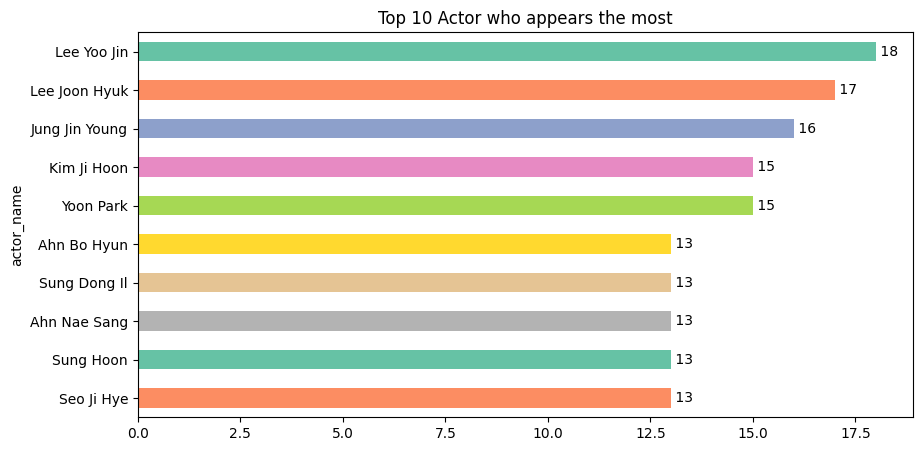

In [10]:
top10_actor = actor.groupby('actor_name').size().sort_values(ascending=False).head(10)

fig= plt.figure(figsize=(10,5))
top10_actor.plot(kind='barh', color=sns.color_palette('Set2')).invert_yaxis()
# Add value labels
for i, v in enumerate(top10_actor):
    plt.text(v, i, f' {v:,}', va='center')
plt.title('Top 10 Actor who appears the most')

2. Visualize Top 10 actors who played main role

Text(0.5, 1.0, 'Top 10 Actor Who Played Main Role the Most')

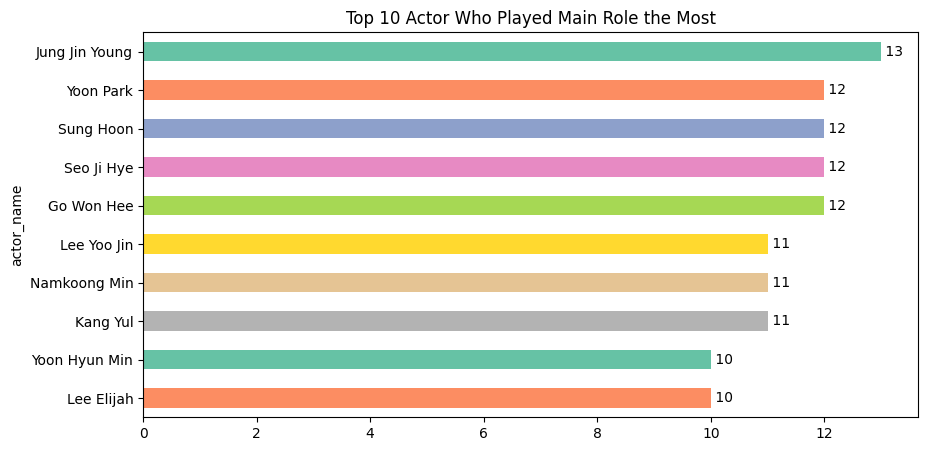

In [11]:
main_role = actor[actor['role'] =='Main Role']
top10_actor_main = main_role.groupby('actor_name').size().sort_values(ascending=False).head(10)

fig= plt.figure(figsize=(10,5))
top10_actor_main.plot(kind='barh', color=sns.color_palette('Set2')).invert_yaxis()
# Add value labels
for i, v in enumerate(top10_actor_main):
    plt.text(v, i, f' {v:,}', va='center')
plt.title('Top 10 Actor Who Played Main Role the Most')

3. Visualize Top 10 actors who played supporting role

Text(0.5, 1.0, 'Top 10 Actors Who Played Supporting Role the Most')

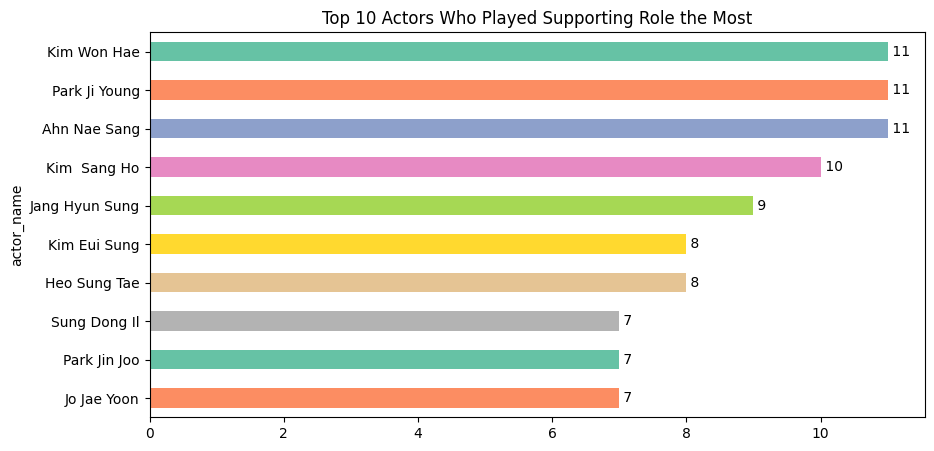

In [12]:
support_role = actor[actor['role'] =='Support Role']
top10_actor_main = support_role.groupby('actor_name').size().sort_values(ascending=False).head(10)

fig= plt.figure(figsize=(10,5))
top10_actor_main.plot(kind='barh', color=sns.color_palette('Set2')).invert_yaxis()
# Add value labels
for i, v in enumerate(top10_actor_main):
    plt.text(v, i, f' {v:,}', va='center')
plt.title('Top 10 Actors Who Played Supporting Role the Most')

## Data Preparation

To create better recommendations, we will focus only on actors who played main roles, as people are usually more interested in watching dramas if their favorite actor plays the main role. To achieve our goals, we need to create a new dataset that contains only main roles.

In [13]:
drama_actor = actor.groupby(['drama_name','role'])['actor_name'].apply(','.join).reset_index()
drama_actor = drama_actor[drama_actor['role'] == 'Main Role']

drama_actor

,drama_name,role,actor_name
0,100 Days My Prince,Main Role,"Doh Kyung Soo,Nam Ji Hyun,Kim Seon Ho"
2,100% Era,Main Role,"Lee Soo Min,Yoo Jung Woo"
4,109 Strange Things,Main Role,"Jung Chae Yeon,Cho Yi Hyun,Choi Tae Joon"
6,18 Again,Main Role,"Lee Do Hyun,Kim Ha Neul,Yoon Sang Hyun"
8,2021 Summer Drama Collage: Monster Mansion,Main Role,"Kim Bo Ra,Sung Joon,Kim Hong Pa"
...,...,...,...
2935,"Yum Yum, How Tasty!",Main Role,Hong Eun Jeong
2936,"Yum Yum, How Tasty! 2",Main Role,"Jung Soo Han,Choi Eun Ji"
2938,Yumi's Cells,Main Role,"Ahn Bo Hyun,Kim Go Eun"
2940,Yumi's Cells Season 2,Main Role,"Kim Go Eun,Park Jin Young"


Since in our recommendation system we only need actor name and drama name, we must select only actor name and drama name columns.

In [14]:
cbf_dataset = drama_actor[['drama_name', 'actor_name']].drop_duplicates(subset="drama_name")
cbf_dataset

,drama_name,actor_name
0,100 Days My Prince,"Doh Kyung Soo,Nam Ji Hyun,Kim Seon Ho"
2,100% Era,"Lee Soo Min,Yoo Jung Woo"
4,109 Strange Things,"Jung Chae Yeon,Cho Yi Hyun,Choi Tae Joon"
6,18 Again,"Lee Do Hyun,Kim Ha Neul,Yoon Sang Hyun"
8,2021 Summer Drama Collage: Monster Mansion,"Kim Bo Ra,Sung Joon,Kim Hong Pa"
...,...,...
2935,"Yum Yum, How Tasty!",Hong Eun Jeong
2936,"Yum Yum, How Tasty! 2","Jung Soo Han,Choi Eun Ji"
2938,Yumi's Cells,"Ahn Bo Hyun,Kim Go Eun"
2940,Yumi's Cells Season 2,"Kim Go Eun,Park Jin Young"


The next step is to create a vectorizer. A vectorizer splits the data in the actor_name column by individual actor names. This allows us to extract each actor's name separately. To achieve this, we can use a TF-IDF vectorizer with a regular expression (regex) for splitting. Then, we fit and transform the data. As a result, we obtain a table where the columns represent all the actors in the dataset, and the rows represent all the dramas in the dataset. The cell values represent a weighted score based on how important the term (actor name) is within the drama and across all dramas.

In [15]:
#Vectorization to seperate the actor name
import re
re_exp = r"\,"
vectorizer = TfidfVectorizer(tokenizer=lambda text: re.split(re_exp,text))

# calculae idf
vectorizer.fit(cbf_dataset['actor_name'])

# matrix transformation
tfidf_matrix = vectorizer.transform(cbf_dataset['actor_name'])

# Take a look to the matrix tfidf shape
tfidf_matrix.shape

/usr/local/lib/python3.10/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


(1628, 2114)

In [16]:
# Changes tf-idf in matrix form
tfidf_matrix.todense()

pd.DataFrame(
    tfidf_matrix.todense(),
    columns=vectorizer.get_feature_names_out(),
    index=cbf_dataset.drama_name
).sample(14, axis=1).sample(20, axis=0)

,lee jin yi,choi woo jung,nam sang ji,kang tae joo,lee jin wook,lee tae im,kang se hyung,lee sun ho,baek jin hee,lee ji yeon,lim young ju,lee jin hyuk,cha yoo jin,lee mi so
drama_name,,,,,,,,,,,,,,
Gracious Revenge,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
Boys Dormitory,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
Shining Na Ra,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
Last,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
All the Love in the World Season 3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
Blueming,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
Casting a Spell to You,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
Afternoon in a Small City,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
Madame Antoine,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0


Next, we calculate the cosine similarity between each drama. Cosine similarity helps determine how similar one drama is to another based on the presence or absence of actors. After calculating the similarity values, we can sort them and use the results to make recommendations.

In [17]:
from sklearn.metrics.pairwise import cosine_similarity

# Calculate cosine similarity
cosine_sim = cosine_similarity(tfidf_matrix)
cosine_sim

array([[1.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 1.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 1.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 1.        , 0.50983408,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.50983408, 1.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        1.        ]])

In [18]:
# Create dataframe from cosine_sim
cosine_sim_df = pd.DataFrame(cosine_sim, index=cbf_dataset.drama_name, columns=cbf_dataset.drama_name)
print('Shape:', cosine_sim_df.shape)

# The Result
cosine_sim_df

Shape: (1628, 1628)


drama_name,100 Days My Prince,100% Era,109 Strange Things,18 Again,2021 Summer Drama Collage: Monster Mansion,20th Century Boy and Girl,22 Flower Road,28 Faces of the Moon,2PM Campus,300 Year-Old Class of 2020,...,Youth Again,Youth Syndrome,Youth of May,Youtuber Class,Youtuber Class Season 2,"Yum Yum, How Tasty!","Yum Yum, How Tasty! 2",Yumi's Cells,Yumi's Cells Season 2,Zombie Detective
drama_name,,,,,,,,,,,,,,,,,,,,,
100 Days My Prince,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
100% Era,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
109 Strange Things,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
18 Again,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.259969,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
2021 Summer Drama Collage: Monster Mansion,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Yum Yum, How Tasty!",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,1.0,0.0,0.000000,0.000000,0.0
"Yum Yum, How Tasty! 2",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,1.0,0.000000,0.000000,0.0
Yumi's Cells,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,1.000000,0.509834,0.0


Finally, after completing the steps above, we can make recommendations. We create a drama_recommendations function to achieve this. This function takes four arguments:

1. drama_name: The name of the drama for which recommendations are to be made.

2. similarity_matrix: The similarity matrix calculated earlier.

3. dataset: The dataset containing all the dramas and their details.

4. k: Refers to the number of top recommendations to return.

In [19]:
#Make Recommendation

def drama_recommendations(drama_name, similarity_data=cosine_sim_df,
                          items=cbf_dataset[['drama_name', 'actor_name']],
                          k=5):

  index = similarity_data.loc[:,drama_name].to_numpy().argpartition(
      range(-1, -k, -1))


  closest = similarity_data.columns[index[-1:-(k+2):-1]]

  closest = closest.drop(drama_name, errors='ignore')
  print(k, "Rekomendasi Drama untuk Drama", drama_name)
  result =pd.DataFrame(closest).merge(items).head(k)
  result['similaritas'] = [similarity_data[drama_name][i] for i in closest]

  return result

Now, we can try our model. We can try to make recommendation for drama "Military Prosecutor Doberman" as follow:

In [20]:
# Get 10 recommendation of "Military Prosecutor Doberman" drama
recomendation = drama_recommendations('Military Prosecutor Doberman', k=10)
recomendation

10 Rekomendasi Drama untuk Drama Military Prosecutor Doberman


,drama_name,actor_name,similaritas
0,Finland Papa,"Kim Bo Ra,Kim Woo Seok",0.308910
1,Yumi's Cells,"Ahn Bo Hyun,Kim Go Eun",0.287922
2,Ghost VRos,"Kim Woo Seok,One",0.277581
3,The Forbidden Marriage,"Kim Woo Seok,Kim Young Dae,Park Ju Hyun",0.249320
4,Hide and Seek,"Lee Yoo Ri,Kim Young Min,Uhm Hyun Kyung,Song C...",0.233388
5,Scripting Your Destiny,"Kim Woo Seok,Jeon So Nee,Ki Do Hoon",0.232406
6,My Name,"Ahn Bo Hyun,Park Hee Soon,Han So Hee",0.231638
7,Missing Noir M,"Park Hee Soon,Jo Bo Ah,Kim Kang Woo",0.229943
8,Tale of the Nine-Tailed,"Lee Dong Wook,Kim Bum,Jo Bo Ah",0.229943
9,My Strange Hero,"Kwak Dong Yeon,Jo Bo Ah,Yoo Seung Ho",0.228510


Looks like we achive our goals!!!

Now, we must evaluate our model to know how great our model is.

## Evaluation

The evaluation metrix we used are Recall, Precision, and F1. We done that manually as follow:

In [26]:
#Get all the actor who starred Military Prosecutor Doberman drama
list_actor = drama_actor.loc[drama_actor.drama_name == "Military Prosecutor Doberman"].actor_name.values
list_actor = list_actor[0].split(",")
list_actor

['Ahn Bo Hyun', 'Kim Woo Seok', 'Jo Bo Ah', 'Oh Yeon Soo', 'Kim Young Min']

In [27]:
#Get all the actor who starred all the drama in the recommendation
actor_rekomendation = recomendation.actor_name.values
actor_rekomendation

array(['Kim Bo Ra,Kim Woo Seok', 'Ahn Bo Hyun,Kim Go Eun',
       'Kim Woo Seok,One', 'Kim Woo Seok,Kim Young Dae,Park Ju Hyun',
       'Lee Yoo Ri,Kim Young Min,Uhm Hyun Kyung,Song Chang Eui',
       'Kim Woo Seok,Jeon So Nee,Ki Do Hoon',
       'Ahn Bo Hyun,Park Hee Soon,Han So Hee',
       'Park Hee Soon,Jo Bo Ah,Kim Kang Woo',
       'Lee Dong Wook,Kim Bum,Jo Bo Ah',
       'Kwak Dong Yeon,Jo Bo Ah,Yoo Seung Ho'], dtype=object)

In [29]:
#Calculate the dramas in our recommendation that have the same actors as the drama "Military Prosecutor Doberman"
score=0
for i in actor_rekomendation:
  if any(x in list_actor for x in i.split(",")):
    score+=1

score

10

All the drama in our recommendation have the same actors as the drama "Military Prosecutor Doberman"

In [24]:
#Calculate all dramas in the dataset that have the same actors as the drama "Military Prosecutor Doberman"
condition = list_actor[0]+"|"+list_actor[1]
condition
print(len(cbf_dataset[cbf_dataset["actor_name"].str.contains(condition)]))
cbf_dataset[cbf_dataset["actor_name"].str.contains(condition)]

13


,drama_name,actor_name
100,After the Show Ends,"Ahn Bo Hyun,Yura,Ha Seok Jin,Yoon So Hee,Lee M..."
567,Dokgo Rewind,"Ahn Bo Hyun,Oh Se Hun,Kang Mi Na,Cho Byeong Kyu"
692,Finland Papa,"Kim Bo Ra,Kim Woo Seok"
753,Ghost VRos,"Kim Woo Seok,One"
1094,Kairos,"Ahn Bo Hyun,Lee Se Young,Shin Sung Rok,Nam Gyu Ri"
1388,Military Prosecutor Doberman,"Ahn Bo Hyun,Kim Woo Seok,Jo Bo Ah,Oh Yeon Soo,..."
1563,My Name,"Ahn Bo Hyun,Park Hee Soon,Han So Hee"
2023,Scripting Your Destiny,"Kim Woo Seok,Jeon So Nee,Ki Do Hoon"
2052,See You in My 19th Life,"Shin Hye Sun,Ahn Bo Hyun,Ha Yoon Kyung,Ahn Don..."
2356,The Forbidden Marriage,"Kim Woo Seok,Kim Young Dae,Park Ju Hyun"


In total, we have 13 drama in our dataset that have the same actor as "Military Prosecutor Doberman" drama.

Now, we can calculate the precision and accuration of our model as follow:


$$presisi = \frac{TP}{TP+FP}$$

$$akurasi = \frac{TP+TN}{TP+TN+FP+FN}$$

whereas
TP : "The number of recommended dramas featuring at least one actor from the drama 'Military Prosecutor Doberman.'"
FP : "The number of recommended dramas that do not feature any actor from the drama 'Military Prosecutor Doberman.'"
FN: Dramas featuring at least one actor from 'Military Prosecutor Doberman' but not included in the recommendation list."
TN: Dramas that do not feature any actor from 'Military Prosecutor Doberman' and are not included in the recommendation list.

From our calcutation we got:
TP = 10
FP = 0
FN = 3
TN = 1615

so,

$$presisi = \frac{10}{10} = 1$$
$$akurasi = \frac{1625}{1628} = 0,9981..$$

## Conclusion

1. A recommendation system using content-based filtering can be created by measuring the similarity of each cast member in a drama.

2. The resulting recommendations demonstrate good performance.